In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [ ]:
df=pd.read_excel("/content/uncleaned_employee_hr_50_rows.xlsx")
print(df)

   Employee_ID    Name          Age  Department             Job_Title  \
0         E006    Anil  twenty five          IT          IT Executive   
1         E007   Pooja           23          HR          HR Executive   
2         E008  Vikram           24     Finance     Finance Executive   
3         E009  Sunita           25       Sales       Sales Executive   
4         E010    Ajay           26  Operations  Operations Executive   
5         E011    Neha           27          IT          IT Executive   
6         E012   Kiran           28          HR          HR Executive   
7         E013  Suresh           29     Finance     Finance Executive   
8         E014   Meena           30       Sales       Sales Executive   
9         E015   Rohit  twenty five  Operations  Operations Executive   
10        E016    Anil           32          IT          IT Executive   
11        E017   Pooja           33          HR          HR Executive   
12        E018  Vikram           34     Finance    

# ***Data Inspection***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Employee_ID         50 non-null     object        
 1   Name                50 non-null     object        
 2   Age                 50 non-null     object        
 3   Department          50 non-null     object        
 4   Job_Title           50 non-null     object        
 5   Joining_Date        50 non-null     datetime64[ns]
 6   Salary              50 non-null     int64         
 7   Experience_Years    43 non-null     float64       
 8   Performance_Rating  50 non-null     object        
 9   Email               42 non-null     object        
 10  Location            43 non-null     object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 4.4+ KB


In [ ]:
df.head()

,Employee_ID,Name,Age,Department,Job_Title,Joining_Date,Salary,Experience_Years,Performance_Rating,Email,Location
0,E006,Anil,twenty five,IT,IT Executive,2023-01-01,30000,NaN,Good,NaN,Bangalore
1,E007,Pooja,23,HR,HR Executive,2023-02-02,35000,1.0,Good,pooja@gmail.com,Delhi
2,E008,Vikram,24,Finance,Finance Executive,2023-03-03,40000,2.0,Good,vikram@gmail.com,Mumbai
3,E009,Sunita,25,Sales,Sales Executive,2023-04-04,45000,3.0,Good,sunita@gmail.com,Chennai
4,E010,Ajay,26,Operations,Operations Executive,2023-05-05,50000,4.0,Good,ajay@gmail.com,Hyderabad


In [ ]:
df.tail()

,Employee_ID,Name,Age,Department,Job_Title,Joining_Date,Salary,Experience_Years,Performance_Rating,Email,Location
45,E051,Neha,twenty five,IT,IT Executive,2023-01-18,55000,5.0,Good,neha@gmail.com,Chennai
46,E052,Kiran,38,HR,HR Executive,2023-02-19,60000,6.0,Good,kiran@gmail.com,Hyderabad
47,E053,Suresh,39,Finance,Finance Executive,2023-03-20,65000,7.0,Good,suresh@gmail.com,Pune
48,E054,Meena,40,Sales,Sales Executive,2023-04-21,70000,NaN,Good,meena@gmail.com,NaN
49,E055,Rohit,41,Operations,Operations Executive,2023-05-22,75000,9.0,Good,NaN,Bangalore


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Name,0
Age,0
Department,0
Job_Title,0
Joining_Date,0
Salary,0
Experience_Years,7
Performance_Rating,0
Email,8


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
df.describe()

,Joining_Date,Salary,Experience_Years
count,50,50.000000,43.000000
mean,2023-05-07 21:07:12,52500.000000,8.767442
min,2023-01-01 00:00:00,30000.000000,0.000000
25%,2023-03-02 06:00:00,40000.000000,4.000000
50%,2023-05-04 12:00:00,52500.000000,8.000000
75%,2023-07-13 00:00:00,65000.000000,13.500000
max,2023-09-27 00:00:00,75000.000000,19.000000
std,NaN,14507.211437,5.723124


In [ ]:
df.dtypes

,0
Employee_ID,object
Name,object
Age,object
Department,object
Job_Title,object
Joining_Date,datetime64[ns]
Salary,int64
Experience_Years,float64
Performance_Rating,object
Email,object


In [ ]:
df.columns

Index(['Employee_ID', 'Name', 'Age', 'Department', 'Job_Title', 'Joining_Date',
       'Salary', 'Experience_Years', 'Performance_Rating', 'Email',
       'Location'],
      dtype='object')

In [ ]:
df.shape

(50, 11)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.nunique()

,0
Employee_ID,50
Name,10
Age,30
Department,5
Job_Title,5
Joining_Date,50
Salary,10
Experience_Years,20
Performance_Rating,1
Email,10


# ***Data Cleaning***

In [ ]:
df['Age']=df['Age'].replace('twenty five','25')
print(df)

   Employee_ID    Name Age  Department             Job_Title Joining_Date  \
0         E006    Anil  25          IT          IT Executive   2023-01-01   
1         E007   Pooja  23          HR          HR Executive   2023-02-02   
2         E008  Vikram  24     Finance     Finance Executive   2023-03-03   
3         E009  Sunita  25       Sales       Sales Executive   2023-04-04   
4         E010    Ajay  26  Operations  Operations Executive   2023-05-05   
5         E011    Neha  27          IT          IT Executive   2023-06-06   
6         E012   Kiran  28          HR          HR Executive   2023-07-07   
7         E013  Suresh  29     Finance     Finance Executive   2023-08-08   
8         E014   Meena  30       Sales       Sales Executive   2023-09-09   
9         E015   Rohit  25  Operations  Operations Executive   2023-01-10   
10        E016    Anil  32          IT          IT Executive   2023-02-11   
11        E017   Pooja  33          HR          HR Executive   2023-03-12   

In [ ]:
df.rename(columns={'Experience_Years': 'Experience'},inplace = True)
df.rename(columns={'Performance_Rating': 'Performance'},inplace = True)
print(df)

   Employee_ID    Name Age  Department             Job_Title Joining_Date  \
0         E006    Anil  25          IT          IT Executive   2023-01-01   
1         E007   Pooja  23          HR          HR Executive   2023-02-02   
2         E008  Vikram  24     Finance     Finance Executive   2023-03-03   
3         E009  Sunita  25       Sales       Sales Executive   2023-04-04   
4         E010    Ajay  26  Operations  Operations Executive   2023-05-05   
5         E011    Neha  27          IT          IT Executive   2023-06-06   
6         E012   Kiran  28          HR          HR Executive   2023-07-07   
7         E013  Suresh  29     Finance     Finance Executive   2023-08-08   
8         E014   Meena  30       Sales       Sales Executive   2023-09-09   
9         E015   Rohit  25  Operations  Operations Executive   2023-01-10   
10        E016    Anil  32          IT          IT Executive   2023-02-11   
11        E017   Pooja  33          HR          HR Executive   2023-03-12   

In [ ]:
df['Location'] = df['Location'].fillna('---')
df['Email'] = df['Email'].fillna('---')
print(df)

   Employee_ID    Name Age  Department             Job_Title Joining_Date  \
0         E006    Anil  25          IT          IT Executive   2023-01-01   
1         E007   Pooja  23          HR          HR Executive   2023-02-02   
2         E008  Vikram  24     Finance     Finance Executive   2023-03-03   
3         E009  Sunita  25       Sales       Sales Executive   2023-04-04   
4         E010    Ajay  26  Operations  Operations Executive   2023-05-05   
5         E011    Neha  27          IT          IT Executive   2023-06-06   
6         E012   Kiran  28          HR          HR Executive   2023-07-07   
7         E013  Suresh  29     Finance     Finance Executive   2023-08-08   
8         E014   Meena  30       Sales       Sales Executive   2023-09-09   
9         E015   Rohit  25  Operations  Operations Executive   2023-01-10   
10        E016    Anil  32          IT          IT Executive   2023-02-11   
11        E017   Pooja  33          HR          HR Executive   2023-03-12   

In [ ]:
df['Experience'] = df['Experience'].fillna(method='bfill')
print(df)

   Employee_ID    Name Age  Department             Job_Title Joining_Date  \
0         E006    Anil  25          IT          IT Executive   2023-01-01   
1         E007   Pooja  23          HR          HR Executive   2023-02-02   
2         E008  Vikram  24     Finance     Finance Executive   2023-03-03   
3         E009  Sunita  25       Sales       Sales Executive   2023-04-04   
4         E010    Ajay  26  Operations  Operations Executive   2023-05-05   
5         E011    Neha  27          IT          IT Executive   2023-06-06   
6         E012   Kiran  28          HR          HR Executive   2023-07-07   
7         E013  Suresh  29     Finance     Finance Executive   2023-08-08   
8         E014   Meena  30       Sales       Sales Executive   2023-09-09   
9         E015   Rohit  25  Operations  Operations Executive   2023-01-10   
10        E016    Anil  32          IT          IT Executive   2023-02-11   
11        E017   Pooja  33          HR          HR Executive   2023-03-12   

/tmp/ipython-input-3164840424.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Experience'] = df['Experience'].fillna(method='bfill')


In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.to_excel("cleaned_employee_hr_dataset.xlsx", index=False)

# ***EDA***

In [ ]:
df=pd.read_excel("/content/cleaned_employee_hr_dataset.xlsx")
df

,Employee_ID,Name,Age,Department,Job_Title,Joining_Date,Salary,Experience,Performance,Email,Location
0,E006,Anil,25,IT,IT Executive,2023-01-01,30000,1,Good,---,Bangalore
1,E007,Pooja,23,HR,HR Executive,2023-02-02,35000,1,Good,pooja@gmail.com,Delhi
2,E008,Vikram,24,Finance,Finance Executive,2023-03-03,40000,2,Good,vikram@gmail.com,Mumbai
3,E009,Sunita,25,Sales,Sales Executive,2023-04-04,45000,3,Good,sunita@gmail.com,Chennai
4,E010,Ajay,26,Operations,Operations Executive,2023-05-05,50000,4,Good,ajay@gmail.com,Hyderabad
5,E011,Neha,27,IT,IT Executive,2023-06-06,55000,5,Good,neha@gmail.com,Pune
6,E012,Kiran,28,HR,HR Executive,2023-07-07,60000,6,Good,kiran@gmail.com,---
7,E013,Suresh,29,Finance,Finance Executive,2023-08-08,65000,7,Good,---,Bangalore
8,E014,Meena,30,Sales,Sales Executive,2023-09-09,70000,9,Good,meena@gmail.com,Delhi
9,E015,Rohit,25,Operations,Operations Executive,2023-01-10,75000,9,Good,rohit@gmail.com,Mumbai


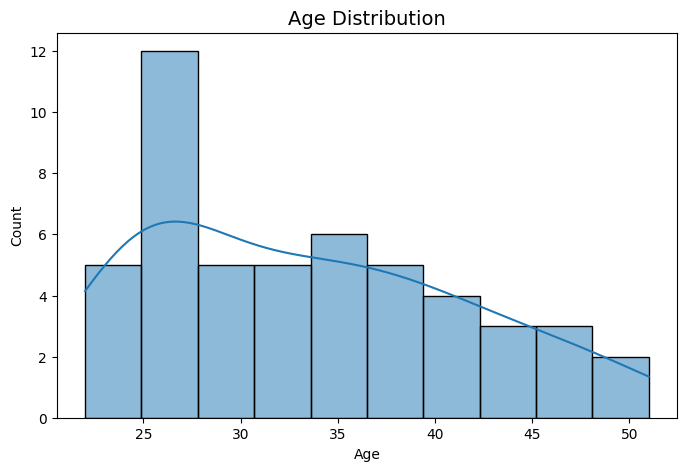

In [ ]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True, color='#1f77b4')
plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

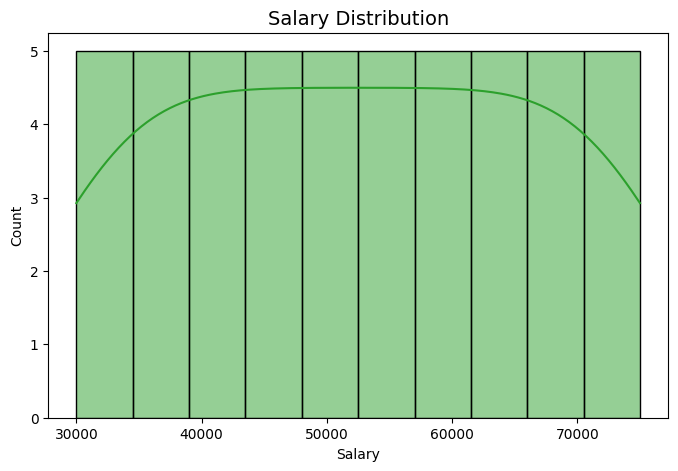

In [ ]:
# Salary Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Salary'], bins=10, kde=True, color='#2ca02c')
plt.title("Salary Distribution", fontsize=14)
plt.xlabel("Salary")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-1691283345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Department', data=df, palette='Set2')


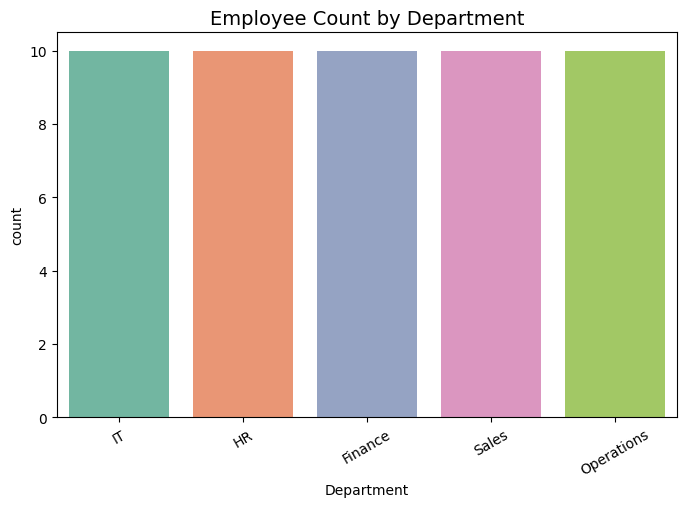

In [ ]:
# Department Counts
plt.figure(figsize=(8,5))
sns.countplot(x='Department', data=df, palette='Set2')
plt.title("Employee Count by Department", fontsize=14)
plt.xticks(rotation=30)
plt.show()

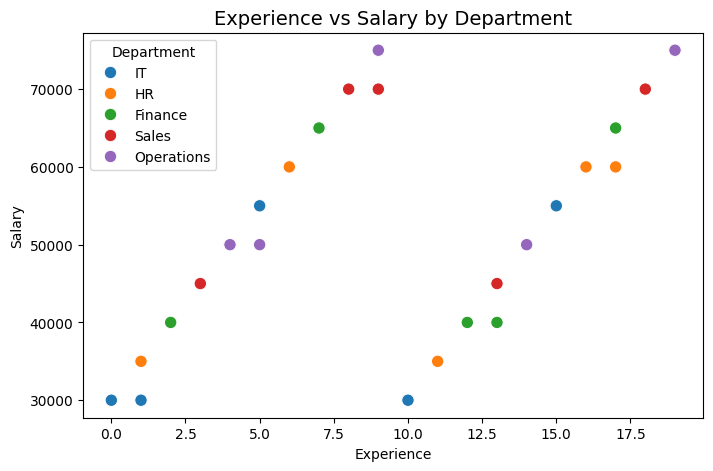

In [ ]:
# Experience vs Salary
plt.figure(figsize=(8,5))
sns.scatterplot(x='Experience', y='Salary', hue='Department',
                data=df, palette='tab10', s=80)
plt.title("Experience vs Salary by Department", fontsize=14)
plt.show()

/tmp/ipython-input-1451482595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Department', y='Salary', data=avg_salary, palette='viridis')


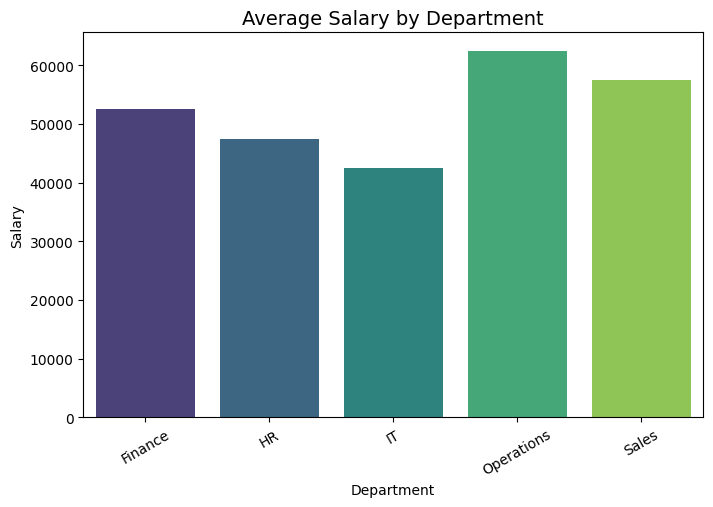

In [ ]:
# Average Salary by Department
avg_salary = df.groupby('Department')['Salary'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Department', y='Salary', data=avg_salary, palette='viridis')
plt.title("Average Salary by Department", fontsize=14)
plt.xticks(rotation=30)
plt.show()

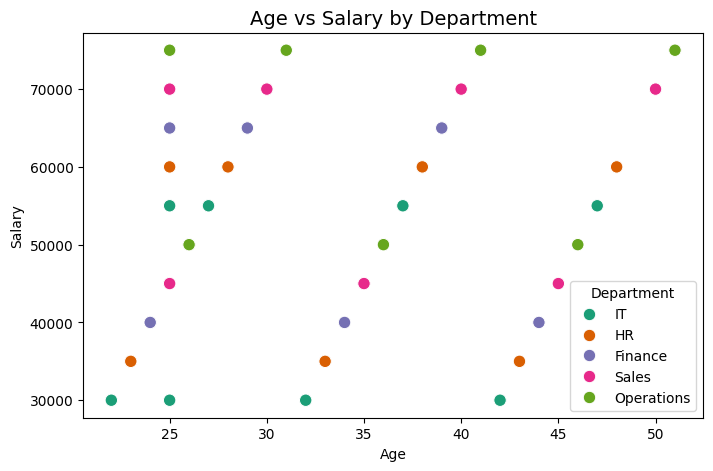

In [ ]:
# Age vs Salary
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Salary', hue='Department',
                data=df, palette='Dark2', s=80)
plt.title("Age vs Salary by Department", fontsize=14)
plt.show()


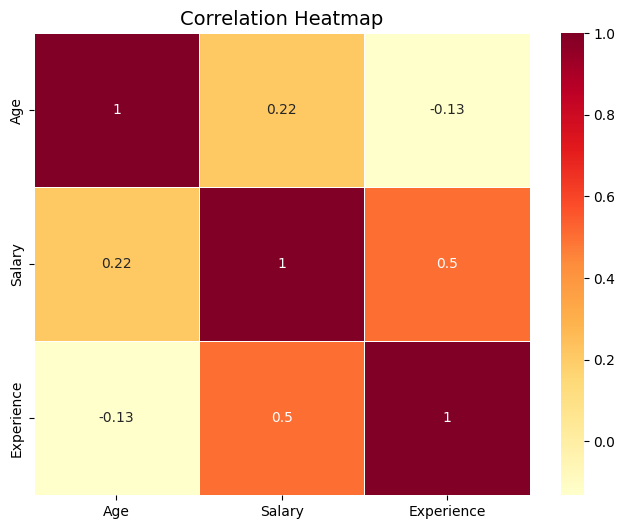

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','Salary','Experience']].corr(),
            annot=True, cmap='YlOrRd', linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

# ***Feature Engineering***

In [ ]:
df = pd.read_excel("/content/cleaned_employee_hr_dataset.xlsx")
df

,Employee_ID,Name,Age,Department,Job_Title,Joining_Date,Salary,Experience,Performance,Email,Location
0,E006,Anil,25,IT,IT Executive,2023-01-01,30000,1,Good,---,Bangalore
1,E007,Pooja,23,HR,HR Executive,2023-02-02,35000,1,Good,pooja@gmail.com,Delhi
2,E008,Vikram,24,Finance,Finance Executive,2023-03-03,40000,2,Good,vikram@gmail.com,Mumbai
3,E009,Sunita,25,Sales,Sales Executive,2023-04-04,45000,3,Good,sunita@gmail.com,Chennai
4,E010,Ajay,26,Operations,Operations Executive,2023-05-05,50000,4,Good,ajay@gmail.com,Hyderabad
5,E011,Neha,27,IT,IT Executive,2023-06-06,55000,5,Good,neha@gmail.com,Pune
6,E012,Kiran,28,HR,HR Executive,2023-07-07,60000,6,Good,kiran@gmail.com,---
7,E013,Suresh,29,Finance,Finance Executive,2023-08-08,65000,7,Good,---,Bangalore
8,E014,Meena,30,Sales,Sales Executive,2023-09-09,70000,9,Good,meena@gmail.com,Delhi
9,E015,Rohit,25,Operations,Operations Executive,2023-01-10,75000,9,Good,rohit@gmail.com,Mumbai


In [ ]:
# Salary per year of experience
df['salary_per_experience'] = df['Salary'] / (df['Experience'] + 1)

In [ ]:
# Age group feature
df['age_group'] = pd.cut(df['Age'],
                          bins=[20, 30, 40, 50, 60],
                          labels=['Young', 'Mid', 'Senior', 'Very Senior'])

In [ ]:
# 2. Encode Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
# Label Encoding
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# 3. Feature Scaling
scaler = StandardScaler()
num_cols = ['Age', 'Salary', 'Experience', 'salary_per_experience']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
# Save final dataset
df.to_excel("final_feature_engineered_dataset.xlsx", index=False)

In [ ]:
df

,Employee_ID,Name,Age,Department,Job_Title,Joining_Date,Salary,Experience,Performance,Email,Location,salary_per_experience,age_group
0,0,1,-1.039891,2,2,2023-01-01,-1.566699,-1.352469,0,0,1,1.299997,Young
1,1,5,-1.288669,1,1,2023-02-02,-1.218544,-1.352469,0,6,3,1.767751,Young
2,2,9,-1.164280,0,0,2023-03-03,-0.870388,-1.175444,0,10,5,0.988161,Young
3,3,7,-1.039891,4,4,2023-04-04,-0.522233,-0.998419,0,8,2,0.598366,Young
4,4,0,-0.915502,3,3,2023-05-05,-0.174078,-0.821395,0,1,4,0.364489,Young
5,5,4,-0.791113,2,2,2023-06-06,0.174078,-0.644370,0,5,6,0.208571,Young
6,6,2,-0.666724,1,1,2023-07-07,0.522233,-0.467345,0,3,0,0.097201,Young
7,7,8,-0.542336,0,0,2023-08-08,0.870388,-0.290321,0,0,1,0.013674,Young
8,8,3,-0.417947,4,4,2023-09-09,1.218544,0.063729,0,4,3,-0.196816,Young
9,9,6,-1.039891,3,3,2023-01-10,1.566699,0.063729,0,7,5,-0.103265,Young
